In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster

2025-11-11 09:40:38.862572: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-11 09:40:38.865808: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
local=True
if local:
    cluster=LocalCluster(memory_limit='48G')
    client = Client(cluster)
else:
    cluster=SLURMCluster(
        cores=5,#cores per slurm job
        memory="64G",#memory per slurm job
        processes=1,#dask workers per slurm job
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=0:20:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=2)
    client = Client(cluster,
            timeout=f"{10*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s",  # Worker heartbeat interval,
        )

In [3]:
from pathlib import Path

In [4]:
DATA_ROOT=Path("/home/mcn26/project_pi_skr2/shared/tabula_data")
#DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")

In [5]:
mini=scm.scMPRA_data.from_tsv(DATA_ROOT/"simulated/fake_cres_v3.tsv")

In [6]:
mini.set_negative_controls(["nobody","weak"])
mini.set_reference_cell("blood")
mini.ortho_filter()

primordial=scm.ortho()
primordial.criss_cross(client=client,
                       dat=mini)

scMPRAforge: INFO: Dropped 0 of 24 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [7]:
primordial.extract_params(client)

In [8]:
primordial.compute_model_qc()

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns

In [10]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 1.9774204907351658, max 220.973687315239
ct
min 2.0086637727097916, max 221.141075804554


---
---
[0.9999534981068082, 0.9999801591322398, 0.9998859838940135, 0.9999978396553043, 0.9847325867492324, 0.9951134035580818, 0.9949942877992611, 0.9999894403980685, 0.9999439479848707, 0.9999946406765716, 0.9999528236343506]


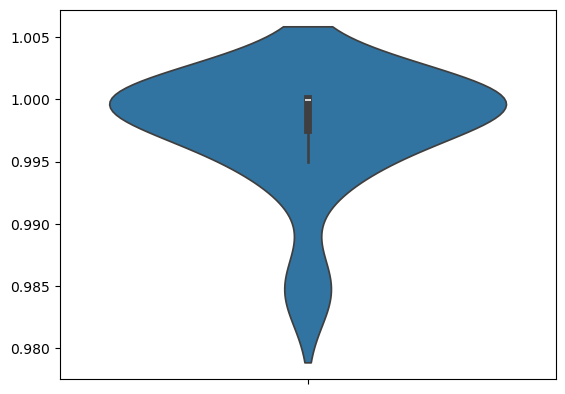

In [11]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Let us take a look at the ZI...

In [15]:
primordial.by_cell_type_parameters.zi["reference"].result()

,zi
rep_id,
2,0.202427
3,0.306070
reference,0.100764


In [20]:
for i in primordial.by_cell_type_parameters.zi:
    print(primordial.by_cell_type_parameters.zi[i].result())

                 zi
rep_id             
2          0.202427
3          0.306070
reference  0.100764
                 zi
rep_id             
2          0.213451
3          0.321898
reference  0.119809
                 zi
rep_id             
2          0.199098
3          0.301334
reference  0.099809


In [21]:
for i in primordial.by_cre_parameters.zi:
    print(primordial.by_cre_parameters.zi[i].result())

                 zi
rep_id             
2          0.206941
3          0.304826
reference  0.092821
                 zi
rep_id             
2          0.214408
3          0.314022
reference  0.101252
                 zi
rep_id             
2          0.192768
3          0.307818
reference  0.092827
                 zi
rep_id             
2          0.195982
3          0.305182
reference  0.105515
                 zi
rep_id             
2          0.203575
3          0.300046
reference  0.111218
                 zi
rep_id             
2          0.195221
3          0.295421
reference  0.100639
                 zi
rep_id             
2          0.192768
3          0.315716
reference  0.104205
                 zi
rep_id             
2          0.197370
3          0.295077
reference  0.108162


In [14]:
cluster.close()
client.close()